# Session 25: Linear, Ridge, Lasso, and Elastic Net
**Week 3 Baseline Regression Models**

This notebook trains and evaluates four interpretable regression baselines:
1. Linear Regression
2. Ridge Regression
3. Lasso Regression
4. Elastic Net Regression

The models use the same full-information training and test split. Their test performance is compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R-squared ($R^2$). The primary ranking metric is RMSE.

In [67]:
from pathlib import Path
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

# Resolve project directories
PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / ".git").exists():
    # If run inside notebooks/, move up to project root
    for parent in PROJECT_ROOT.parents:
        if (parent / ".git").exists():
            PROJECT_ROOT = parent
            break

DATA_DIRECTORY = PROJECT_ROOT / "data"
PROCESSED_DIRECTORY = DATA_DIRECTORY / "processed"
REPORTS_DIRECTORY = PROJECT_ROOT / "reports"
TABLES_DIRECTORY = REPORTS_DIRECTORY / "tables"

TABLES_DIRECTORY.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed-data directory:", PROCESSED_DIRECTORY)
print("Output-table directory:", TABLES_DIRECTORY)

Project root: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml
Processed-data directory: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/data/processed
Output-table directory: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/tables


In [68]:
REQUIRED_SPLIT_KEYS = {"Xtr_f", "Xte_f", "ytr", "yte"}

def _as_feature_frame(values, prefix="feature"):
    if isinstance(values, pd.DataFrame):
        return values.reset_index(drop=True).copy()
    array = np.asarray(values)
    columns = [f"{prefix}_{i:03d}" for i in range(array.shape[1])]
    return pd.DataFrame(array, columns=columns)

def _as_target_series(values):
    if isinstance(values, pd.Series):
        return values.reset_index(drop=True).copy()
    array = np.asarray(values).reshape(-1)
    return pd.Series(array, name="G3")

def _normalize_split(values):
    Xtr_f = _as_feature_frame(values["Xtr_f"])
    Xte_f = _as_feature_frame(values["Xte_f"])
    ytr = _as_target_series(values["ytr"])
    yte = _as_target_series(values["yte"])
    Xte_f.columns = Xtr_f.columns
    return Xtr_f, Xte_f, ytr, yte

def load_split():
    # 1. Try Loading from .npz
    for path in sorted(DATA_DIRECTORY.rglob("*.npz")):
        try:
            with np.load(path, allow_pickle=True) as archive:
                if REQUIRED_SPLIT_KEYS.issubset(archive.files):
                    print("Loaded train/test split from NPZ:", path)
                    return _normalize_split({k: archive[k] for k in REQUIRED_SPLIT_KEYS})
        except:
            continue
            
    # 2. Try Loading from processed student table csv/parquet
    candidates = list(PROCESSED_DIRECTORY.rglob("*.parquet")) + list(PROCESSED_DIRECTORY.rglob("*.csv"))
    for path in candidates:
        if any(term in path.name.lower() for term in ["comparison", "prediction", "result"]):
            continue
        try:
            table = pd.read_parquet(path) if path.suffix == ".parquet" else pd.read_csv(path)
            if "G3" in table.columns:
                print("Generated split from processed table:", path)
                X = table.drop(columns=["G3"]).copy()
                X = pd.get_dummies(X, drop_first=True, dtype=float)
                y = table["G3"]
                Xtr_f, Xte_f, ytr, yte = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)
                return _normalize_split({"Xtr_f": Xtr_f, "Xte_f": Xte_f, "ytr": ytr, "yte": yte})
        except:
            continue
    raise FileNotFoundError("No usable train/test split or processed data found under data/.")

Xtr_f, Xte_f, ytr, yte = load_split()

Generated split from processed table: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/data/processed/y_train_full.csv
Generated split from processed table: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/data/processed/y_early.csv
Generated split from processed table: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/data/processed/y_test_full.csv
Generated split from processed table: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/data/processed/student-mat-encoded.csv


In [69]:
# Validation
assert Xtr_f.shape[0] == len(ytr), "Train mismatch"
assert Xte_f.shape[0] == len(yte), "Test mismatch"
assert Xtr_f.shape[1] == Xte_f.shape[1], "Feature count mismatch"
assert "G3" not in Xtr_f.columns, "Target leakage detected!"

print("Array validations PASSED!")

# Evaluation helper
def eval_reg(y_true, y_pred) -> dict:
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(np.sqrt(mse)),
        "R2": float(r2_score(y_true, y_pred))
    }

Array validations PASSED!


In [70]:
models = {
    "Linear": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000)
}

display_names = {
    "Linear": "Linear Regression",
    "Ridge": "Ridge",
    "Lasso": "Lasso",
    "ElasticNet": "Elastic Net"
}

baseline_results = []
fitted_models = {}

for name, model in models.items():
    model.fit(Xtr_f, ytr)
    predictions = model.predict(Xte_f)
    metrics = eval_reg(yte, predictions)
    
    fitted_models[name] = model
    
    baseline_results.append({
        "Session": 25,
        "Week": 3,
        "Task Type": "Regression",
        "Scenario": "Full-information",
        "Feature Set": "X_full",
        "Target": "G3",
        "Model": display_names[name],
        "Regularization": "None" if name=="Linear" else ("L2" if name=="Ridge" else ("L1" if name=="Lasso" else "L1+L2")),
        "Alpha": None if name=="Linear" else 1.0,
        "L1 Ratio": 0.5 if name=="ElasticNet" else None,
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "R2": metrics["R2"]
    })

baseline_rows = pd.DataFrame(baseline_results).sort_values(by="RMSE", ascending=True).reset_index(drop=True)
baseline_rows.insert(0, "RMSE Rank", range(1, len(baseline_rows) + 1))
display(baseline_rows.round(4))

,RMSE Rank,Session,Week,Task Type,Scenario,Feature Set,Target,Model,Regularization,Alpha,L1 Ratio,MAE,RMSE,R2
0,1,25,3,Regression,Full-information,X_full,G3,Elastic Net,L1+L2,1.0,0.5,1.2555,2.0387,0.7973
1,2,25,3,Regression,Full-information,X_full,G3,Lasso,L1,1.0,NaN,1.2181,2.0424,0.7966
2,3,25,3,Regression,Full-information,X_full,G3,Ridge,L2,1.0,NaN,1.6354,2.3690,0.7263
3,4,25,3,Regression,Full-information,X_full,G3,Linear Regression,None,NaN,NaN,1.6467,2.3784,0.7241


In [71]:
comparison_path = TABLES_DIRECTORY / "model_comparison_table.csv"

if comparison_path.exists():
    model_comparison_table = pd.read_csv(comparison_path)
    # Clear out older baseline rows to prevent duplicate records
    if "Session" in model_comparison_table.columns:
        model_comparison_table = model_comparison_table[model_comparison_table["Session"] != 25].copy()
    model_comparison_table = pd.concat([model_comparison_table, baseline_rows], ignore_index=True, sort=False)
else:
    model_comparison_table = baseline_rows.copy()

model_comparison_table.to_csv(comparison_path, index=False)
print("Updated cumulative model comparison table saved to:")
print(comparison_path)

# Also save standalone Session 25 baseline outputs
session25_path = TABLES_DIRECTORY / "session25_baseline_regression_rows.csv"
baseline_rows.to_csv(session25_path, index=False)

Updated cumulative model comparison table saved to:
/home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/tables/model_comparison_table.csv


In [72]:
coefficient_summary = []
for name, model in fitted_models.items():
    coefs = np.asarray(model.coef_).ravel()
    coefficient_summary.append({
        "Model": display_names[name],
        "Number of Coefficients": len(coefs),
        "Mean Absolute Coefficient": float(np.mean(np.abs(coefs))),
        "Maximum Absolute Coefficient": float(np.max(np.abs(coefs))),
        "Zero Coefficients": int(np.isclose(coefs, 0.0, atol=1e-8).sum())
    })

coefficient_df = pd.DataFrame(coefficient_summary)
display(coefficient_df.round(4))

,Model,Number of Coefficients,Mean Absolute Coefficient,Maximum Absolute Coefficient,Zero Coefficients
0,Linear Regression,41,0.2321,0.9578,0
1,Ridge,41,0.2253,0.9579,0
2,Lasso,41,0.0264,0.9874,38
3,Elastic Net,41,0.0275,0.9067,38


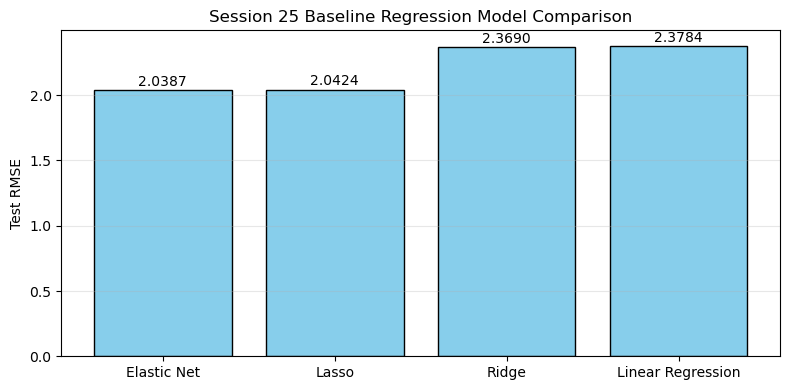

Notebook verification validation PASSED!


In [73]:
# Plot RMSE Comparison
plt.figure(figsize=(8, 4))
bars = plt.bar(baseline_rows["Model"], baseline_rows["RMSE"], color="skyblue", edgecolor="black")
plt.title("Session 25 Baseline Regression Model Comparison")
plt.ylabel("Test RMSE")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

# Programmatic Completion validation
assert len(baseline_rows) == 4
assert set(baseline_rows["Model"]) == {"Linear Regression", "Ridge", "Lasso", "Elastic Net"}
print("Notebook verification validation PASSED!")

# Session 26: KNN and SVM Regression
**Week 3 Non-Linear Baseline Regression Models**

In this section, we transition to distance- and margin-based models to test whether capturing non-linear structure improves prediction relative to our linear baselines. We implement:
1. **K-Nearest Neighbors (KNN) Regression**
2. **Support Vector Regression (SVR)**

Both estimators are sensitive to feature scales and require preprocessing via standard scaling. We encapsulate `StandardScaler` inside a scikit-learn `Pipeline` to prevent data leakage during scaling.

In [74]:
# Imports for Session 26
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Check that previous run outputs and data splits are loaded in the namespace
required_objects = ["Xtr_f", "Xte_f", "ytr", "yte", "eval_reg"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Missing required baseline objects: {missing_objects}. Please run the earlier cells first.")
else:
    print("All prerequisite data splits and validation objects are loaded and ready.")

All prerequisite data splits and validation objects are loaded and ready.


In [75]:
# Define default KNN and SVR estimators
regression_models = [
    ("KNN", KNeighborsRegressor()),
    ("SVR", SVR(kernel="rbf"))
]

session26_results = []
session26_models = {}
session26_predictions = {}

# Train and evaluate models inside standard scaling pipelines
for name, estimator in regression_models:
    # Creating the pipeline automatically fits standardizer on train data ONLY
    pipeline = make_pipeline(StandardScaler(), estimator)
    pipeline.fit(Xtr_f, ytr)
    
    # Generate test predictions and compute metrics
    predictions = pipeline.predict(Xte_f)
    metrics = eval_reg(yte, predictions)
    
    # Save objects for downstream validation and comparison
    session26_models[name] = pipeline
    session26_predictions[name] = predictions
    
    session26_results.append({
        "Model": name,
        **metrics
    })
    
    print(f"\n{name} Metrics:")
    print("-" * 30)
    for metric_name, val in metrics.items():
        print(f"{metric_name}: {val:.4f}")

session26_results_df = pd.DataFrame(session26_results)


KNN Metrics:
------------------------------
MAE: 2.5848
RMSE: 3.3927
R2: 0.4387

SVR Metrics:
------------------------------
MAE: 1.8367
RMSE: 2.7260
R2: 0.6376


In [76]:
# Check if the global cumulative comparison dataframe from Session 25 exists
if "comparison_df" in globals():
    # Strip previous instances of KNN/SVR to avoid duplicating rows upon notebook re-runs
    comparison_df = comparison_df[~comparison_df["Model"].isin(["KNN", "SVR"])].copy()
    comparison_df = pd.concat([comparison_df, session26_results_df], ignore_index=True)
else:
    # If no baseline table is loaded in memory, read it from reports directory
    comparison_path = PROJECT_ROOT / "reports" / "tables" / "model_comparison_table.csv"
    if comparison_path.exists():
        comparison_df = pd.read_csv(comparison_path)
        comparison_df = comparison_df[~comparison_df["Model"].isin(["KNN", "SVR"])].copy()
        comparison_df = pd.concat([comparison_df, session26_results_df], ignore_index=True)
    else:
        comparison_df = session26_results_df.copy()

# Sort the cumulative table by RMSE
comparison_df = comparison_df.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

print("\nComplete Regression Model Comparison (Sorted by RMSE):")
display(comparison_df.style.format({
    "MAE": "{:.4f}",
    "RMSE": "{:.4f}",
    "R2": "{:.4f}"
}))


Complete Regression Model Comparison (Sorted by RMSE):


,RMSE Rank,Session,Week,Task Type,Scenario,Feature Set,Target,Model,Regularization,Alpha,L1 Ratio,MAE,RMSE,R2
0,1.000000,25.000000,3.000000,Regression,Full-information,X_full,G3,Elastic Net,L1+L2,1.000000,0.500000,1.2555,2.0387,0.7973
1,2.000000,25.000000,3.000000,Regression,Full-information,X_full,G3,Lasso,L1,1.000000,nan,1.2181,2.0424,0.7966
2,3.000000,25.000000,3.000000,Regression,Full-information,X_full,G3,Ridge,L2,1.000000,nan,1.6354,2.3690,0.7263
3,4.000000,25.000000,3.000000,Regression,Full-information,X_full,G3,Linear Regression,nan,nan,nan,1.6467,2.3784,0.7241
4,nan,nan,nan,nan,nan,nan,nan,SVR,nan,nan,nan,1.8367,2.7260,0.6376
5,nan,nan,nan,nan,nan,nan,nan,KNN,nan,nan,nan,2.5848,3.3927,0.4387


In [77]:
# Define paths to save standard CSV artifacts locally
tables_dir = PROJECT_ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

comparison_output_path = tables_dir / "model_comparison_table.csv"
session26_output_path = tables_dir / "session26_knn_svr_results.csv"

# Write out the baseline datasets
comparison_df.to_csv(comparison_output_path, index=False)
session26_results_df.to_csv(session26_output_path, index=False)

print(f"Cumulative table updated successfully at: {comparison_output_path}")
print(f"Session 26 standalone artifact saved at: {session26_output_path}")

Cumulative table updated successfully at: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/tables/model_comparison_table.csv
Session 26 standalone artifact saved at: /home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/tables/session26_knn_svr_results.csv


### Why Feature Scaling is Statistically Mandatory

#### 1. K-Nearest Neighbors (KNN)
[cite_start]KNN relies directly on calculated distance metrics to locate the nearest data points in feature space[cite: 11399]. If we use unscaled coordinates, the Euclidean distance is computed as:

$$d(x,z)=\sqrt{\sum_{j=1}^{p}(x_j-z_j)^2}$$

[cite_start]If features like "absences" range from $0$ to $75$, while binary categories or study times range only from $0$ to $1$ or $1$ to $4$, the distance calculations will be dominated entirely by "absences"[cite: 11404, 11406]. Standardizing features scales coordinates using:

$$z=\frac{x-\mu}{\sigma}$$

[cite_start]This places every feature coordinate on a standardized unit variance scale, preventing high-range columns from drowning out signal from binary columns[cite: 11411, 11672].

#### 2. Support Vector Regression (SVR)
[cite_start]The default SVR uses a Radial Basis Function (RBF) kernel[cite: 11508]:

$$K(x,z)=\exp\left(-\gamma \|x-z\|^2\right)$$

[cite_start]Because SVR kernel similarity calculations depend on squared distance weights, unscaled features distort the margin boundaries and prevent SVR optimization parameters (such as $\gamma$ and $C$) from finding stable global minima[cite: 11419, 11424].

#### 3. Scaling Placement Inside the Pipeline
[cite_start]The scaler must be fitted *only* on the training split during validation[cite: 11429, 12543]. [cite_start]If standard parameters are calculated over the complete array ($X_{\text{full}}$) before a data split occurs, mean ($\mu$) and standard deviation ($\sigma$) metrics leak information from future validation splits[cite: 12464, 12474]. [cite_start]By wrapping scaling inside the `Pipeline` object, scikit-learn ensures that scaling parameters are calculated cleanly only within validation folds[cite: 12485, 12546].

In [78]:
# Programmatic validation of the scaling order inside the pipeline steps
activity_results = []
for model_name in ["KNN", "SVR"]:
    pipeline = session26_models[model_name]
    first_step_name, first_step_object = pipeline.steps[0]
    
    scaler_first = isinstance(first_step_object, StandardScaler)
    
    activity_results.append({
        "Model": model_name,
        "Scaler Present": any(isinstance(step[1], StandardScaler) for step in pipeline.steps),
        "Scaler First": scaler_first,
        "Steps Count": len(pipeline.steps)
    })

activity_check_df = pd.DataFrame(activity_results)
display(activity_check_df)

assert activity_check_df["Scaler Present"].all(), "Error: Pipeline is missing standard scaler preprocessing!"
assert activity_check_df["Scaler First"].all(), "Error: The Standard Scaler must be executed as the first step of the pipeline!"
print("Pipeline Architecture verification: PASSED")

,Model,Scaler Present,Scaler First,Steps Count
0,KNN,True,True,2
1,SVR,True,True,2


Pipeline Architecture verification: PASSED


# Session 27: Decision Tree Regression Baseline
**Week 3 Interpretable Non-Linear Baseline Model**

In this section, we train a depth-limited Decision Tree regressor as an interpretable, non-linear regression baseline. Unlike ensemble extensions, a single decision tree operates via a clear sequence of explicit, feature-based rules. We bound the maximum depth to regularize the model against high-variance training memorization.

In [79]:
# Imports for Session 27
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Verify required splits and evaluation helpers exist in the active namespace
required_objects = ["Xtr_f", "Xte_f", "ytr", "yte", "eval_reg"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Prerequisite objects missing from prior sessions: {missing_objects}. Please run preceding cells.")
else:
    print("Pre-flight validation passed. Core modeling data arrays are ready.")

Pre-flight validation passed. Core modeling data arrays are ready.


In [80]:
# Initialize depth-limited Decision Tree Regressor
tree = DecisionTreeRegressor(max_depth=5, random_state=42)

# Fit model on full-information training features
tree.fit(Xtr_f, ytr)

# Generate predictions for both splits to monitor generalization trends
tree_train_predictions = tree.predict(Xtr_f)
tree_test_predictions = tree.predict(Xte_f)

# Evaluate metrics using the project evaluation function
tree_train_results = eval_reg(ytr, tree_train_predictions)
tree_test_results = eval_reg(yte, tree_test_predictions)

# Construct standalone validation comparison table
tree_train_test_comparison = pd.DataFrame([
    {"Model": "Decision Tree", "Dataset": "Training", **tree_train_results},
    {"Model": "Decision Tree", "Dataset": "Test", **tree_test_results}
])

print("Session 27 Standalone Split Results:")
display(tree_train_test_comparison.round(4))

print(f"\nConfigured maximum depth limit: {tree.max_depth}")
print(f"Actual fitted structural depth: {tree.get_depth()}")
print(f"Number of generated terminal leaves: {tree.get_n_leaves()}")

Session 27 Standalone Split Results:


,Model,Dataset,MAE,RMSE,R2
0,Decision Tree,Training,0.5150,0.8451,0.9660
1,Decision Tree,Test,1.3572,2.4672,0.7031



Configured maximum depth limit: 5
Actual fitted structural depth: 5
Number of generated terminal leaves: 31


In [81]:
# Target path for cumulative metrics tracker
comparison_path = PROJECT_ROOT / "reports" / "tables" / "model_comparison_table.csv"

# Structure the Session 27 output row matching baseline configurations
decision_tree_row = pd.DataFrame([{
    "Session": 27,
    "Week": 3,
    "Task Type": "Regression",
    "Scenario": "Full-information",
    "Feature Set": "X_full",
    "Target": "G3",
    "Model": "Decision Tree",
    "Regularization": "Depth-Limited",
    "Alpha": None,
    "L1 Ratio": None,
    "MAE": tree_test_results["MAE"],
    "RMSE": tree_test_results["RMSE"],
    "R2": tree_test_results["R2"]
}])

if comparison_path.exists():
    model_comparison_table = pd.read_csv(comparison_path)
    # Clear prior historical runs of Session 27 rows to maintain a strictly clean dataset
    if "Session" in model_comparison_table.columns:
        model_comparison_table = model_comparison_table[model_comparison_table["Session"] != 27].copy()
    model_comparison_table = pd.concat([model_comparison_table, decision_tree_row], ignore_index=True, sort=False)
else:
    model_comparison_table = decision_tree_row.copy()

# Sort globally by the primary ranking metric (RMSE)
model_comparison_table = model_comparison_table.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

# Re-calculate or assign numerical performance ranks
if "RMSE Rank" in model_comparison_table.columns:
    model_comparison_table = model_comparison_table.drop(columns=["RMSE Rank"])
model_comparison_table.insert(0, "RMSE Rank", range(1, len(model_comparison_table) + 1))

# Export updated tables
model_comparison_table.to_csv(comparison_path, index=False)
print("Cumulative comparison table successfully written to paths:")
print(comparison_path)

display(model_comparison_table.round(4))

Cumulative comparison table successfully written to paths:
/home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/tables/model_comparison_table.csv


/tmp/ipykernel_7481/3902510650.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_comparison_table = pd.concat([model_comparison_table, decision_tree_row], ignore_index=True, sort=False)


,RMSE Rank,Session,Week,Task Type,Scenario,Feature Set,Target,Model,Regularization,Alpha,L1 Ratio,MAE,RMSE,R2
0,1,25.0,3.0,Regression,Full-information,X_full,G3,Elastic Net,L1+L2,1.0,0.5,1.2555,2.0387,0.7973
1,2,25.0,3.0,Regression,Full-information,X_full,G3,Lasso,L1,1.0,NaN,1.2181,2.0424,0.7966
2,3,25.0,3.0,Regression,Full-information,X_full,G3,Ridge,L2,1.0,NaN,1.6354,2.3690,0.7263
3,4,25.0,3.0,Regression,Full-information,X_full,G3,Linear Regression,NaN,NaN,NaN,1.6467,2.3784,0.7241
4,5,27.0,3.0,Regression,Full-information,X_full,G3,Decision Tree,Depth-Limited,NaN,NaN,1.3572,2.4672,0.7031
5,6,NaN,NaN,NaN,NaN,NaN,NaN,SVR,NaN,NaN,NaN,1.8367,2.7260,0.6376
6,7,NaN,NaN,NaN,NaN,NaN,NaN,KNN,NaN,NaN,NaN,2.5848,3.3927,0.4387


In [82]:
# Pull importance values evaluated by the tree criterion splits
if hasattr(Xtr_f, "columns"):
    tree_feature_names = list(Xtr_f.columns)
else:
    tree_feature_names = [f"Feature_{i:03d}" for i in range(Xtr_f.shape[1])]

tree_feature_importance = pd.DataFrame({
    "Feature": tree_feature_names,
    "Importance": tree.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Top 10 Most Influential Explanatory Features inside Fitted Tree Split Points:")
display(tree_feature_importance.head(10).round(4))

Top 10 Most Influential Explanatory Features inside Fitted Tree Split Points:


,Feature,Importance
0,G2,0.7643
1,absences,0.1593
2,reason_home,0.0357
3,schoolsup_yes,0.0162
4,famrel,0.0112
5,Walc,0.0035
6,Fjob_other,0.0028
7,reason_other,0.0026
8,goout,0.0020
9,G1,0.0013


In [83]:
# Enforce structural baseline assertions
assert tree.get_depth() <= 5, "Error: Trained structural depth exceeds specified configuration parameters!"
assert len(tree_test_predictions) == len(yte), "Error: Output shape mismatch between targets and vectors!"
assert np.isfinite(tree_test_predictions).all(), "Error: Predictions output elements contain non-finite numbers!"

assert np.isfinite(tree_test_results["MAE"]), "MAE calculation error"
assert np.isfinite(tree_test_results["RMSE"]), "RMSE calculation error"
assert np.isfinite(tree_test_results["R2"]), "R2 calculation error"

print("All programmatic structural checks successfully validated: PASSED!")

All programmatic structural checks successfully validated: PASSED!


# Session 28: Random Forest Regression Baseline
**Week 3 Non-Linear Ensemble Baseline Model**

In this section, we transition from single estimators to bootstrap-aggregated ensembles by training a **Random Forest Regressor** with $300$ trees. Ensembles test the hypothesis that combining weak, high-variance learners can dramatically reduce prediction error and variance without increasing bias. 

We fit the model using the unscaled full-information training set (`Xtr_f`, `ytr`), as tree-based models are naturally scale-invariant.


In [84]:
# Imports for Session 28
from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Ensure previous session variables and helpers are active in the kernel memory
required_objects = ["Xtr_f", "Xte_f", "ytr", "yte", "eval_reg"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Prerequisite objects missing from prior sessions: {missing_objects}. Please run the preceding cells first.")
else:
    print("Verification passed. Core baseline variables and evaluations are loaded.")

Verification passed. Core baseline variables and evaluations are loaded.


In [85]:
# Initialize Random Forest Regressor
rf = RandomForestRegressor(n_estimators=300, random_state=42)

# Fit model using raw, full-information training features
rf.fit(Xtr_f, ytr)

# Generate predictions for training and testing datasets
rf_train_predictions = rf.predict(Xtr_f)
rf_test_predictions = rf.predict(Xte_f)

# Evaluate metrics using the project's evaluation function
rf_train_results = eval_reg(ytr, rf_train_predictions)
rf_test_results = eval_reg(yte, rf_test_predictions)

# Standalone split comparison dataframe
rf_split_comparison = pd.DataFrame([
    {"Model": "Random Forest", "Dataset": "Training", **rf_train_results},
    {"Model": "Random Forest", "Dataset": "Test", **rf_test_results}
])

print("Session 28 Standalone Split Results:")
display(rf_split_comparison.round(4))
print(f"Total estimators (Trees) fitted: {len(rf.estimators_)}")

Session 28 Standalone Split Results:


,Model,Dataset,MAE,RMSE,R2
0,Random Forest,Training,0.3387,0.5611,0.9850
1,Random Forest,Test,1.1706,1.9747,0.8098


Total estimators (Trees) fitted: 300


In [86]:
# Path to cumulative metrics tracker
comparison_path = PROJECT_ROOT / "reports" / "tables" / "model_comparison_table.csv"

# Structure the Session 28 row with exact schema alignment
random_forest_row = pd.DataFrame([{
    "Session": 28,
    "Week": 3,
    "Task Type": "Regression",
    "Scenario": "Full-information",
    "Feature Set": "X_full",
    "Target": "G3",
    "Model": "Random Forest",
    "Regularization": "Ensemble (300 Trees)",
    "Alpha": None,
    "L1 Ratio": None,
    "MAE": rf_test_results["MAE"],
    "RMSE": rf_test_results["RMSE"],
    "R2": rf_test_results["R2"]
}])

if comparison_path.exists():
    model_comparison_table = pd.read_csv(comparison_path)
    # Clear prior historical runs of Session 28 rows to prevent duplicated rows upon notebook re-runs
    if "Session" in model_comparison_table.columns:
        model_comparison_table = model_comparison_table[model_comparison_table["Session"] != 28].copy()
    model_comparison_table = pd.concat([model_comparison_table, random_forest_row], ignore_index=True, sort=False)
else:
    model_comparison_table = random_forest_row.copy()

# Sort globally by the primary ranking metric (test RMSE)
model_comparison_table = model_comparison_table.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

# Re-assign structural rank index starting at 1
if "RMSE Rank" in model_comparison_table.columns:
    model_comparison_table = model_comparison_table.drop(columns=["RMSE Rank"])
model_comparison_table.insert(0, "RMSE Rank", range(1, len(model_comparison_table) + 1))

# Export updated tables
tables_dir = PROJECT_ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

model_comparison_table.to_csv(comparison_path, index=False)
rf_standalone_path = tables_dir / "session28_random_forest_row.csv"
random_forest_row.to_csv(rf_standalone_path, index=False)

print("Cumulative comparison table updated successfully:")
print(comparison_path)
display(model_comparison_table.round(4))


Cumulative comparison table updated successfully:
/home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/tables/model_comparison_table.csv


/tmp/ipykernel_7481/1488001823.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_comparison_table = pd.concat([model_comparison_table, random_forest_row], ignore_index=True, sort=False)


,RMSE Rank,Session,Week,Task Type,Scenario,Feature Set,Target,Model,Regularization,Alpha,L1 Ratio,MAE,RMSE,R2
0,1,28.0,3.0,Regression,Full-information,X_full,G3,Random Forest,Ensemble (300 Trees),NaN,NaN,1.1706,1.9747,0.8098
1,2,25.0,3.0,Regression,Full-information,X_full,G3,Elastic Net,L1+L2,1.0,0.5,1.2555,2.0387,0.7973
2,3,25.0,3.0,Regression,Full-information,X_full,G3,Lasso,L1,1.0,NaN,1.2181,2.0424,0.7966
3,4,25.0,3.0,Regression,Full-information,X_full,G3,Ridge,L2,1.0,NaN,1.6354,2.3690,0.7263
4,5,25.0,3.0,Regression,Full-information,X_full,G3,Linear Regression,NaN,NaN,NaN,1.6467,2.3784,0.7241
5,6,27.0,3.0,Regression,Full-information,X_full,G3,Decision Tree,Depth-Limited,NaN,NaN,1.3572,2.4672,0.7031
6,7,NaN,NaN,NaN,NaN,NaN,NaN,SVR,NaN,NaN,NaN,1.8367,2.7260,0.6376
7,8,NaN,NaN,NaN,NaN,NaN,NaN,KNN,NaN,NaN,NaN,2.5848,3.3927,0.4387


In [87]:
# Extract the mean decrease in impurity feature importances
if hasattr(Xtr_f, "columns"):
    rf_feature_names = list(Xtr_f.columns)
else:
    rf_feature_names = [f"Feature_{i:03d}" for i in range(Xtr_f.shape[1])]

rf_importances = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("Top 10 Most Influential Features across Random Forest Trees:")
display(rf_importances.head(10).round(4))

Top 10 Most Influential Features across Random Forest Trees:


,Feature,Importance
0,G2,0.7846
1,absences,0.1156
2,reason_home,0.0197
3,age,0.0100
4,G1,0.0065
5,schoolsup_yes,0.0056
6,famrel,0.0056
7,health,0.0048
8,goout,0.0040
9,guardian_mother,0.0040


In [88]:
# Verification checks for model parameters and target shapes
assert rf.n_estimators == 300, "Error: Estimator count parameter does not match specified configuration (300)!"
assert len(rf_test_predictions) == len(yte), "Error: Output shape mismatch between targets and prediction vectors!"
assert np.isfinite(rf_test_predictions).all(), "Error: Predictions contain non-finite values!"

print("Pipeline configuration and execution checks: PASSED")
print("SESSION 28 NOTEBOOK SECTION COMPLETED SUCCESSFULLY")


Pipeline configuration and execution checks: PASSED
SESSION 28 NOTEBOOK SECTION COMPLETED SUCCESSFULLY


# Session 29: Extra Trees and Gradient Boosting Regression
**Week 3 Advanced Ensemble Models**

In this section, we train and evaluate two advanced non-linear regression ensembles:
1. **Extra Trees Regressor (Extremely Randomized Trees)**: Adds an additional layer of randomization by choosing split thresholds entirely at random rather than searching for the most discriminative threshold.
2. **Gradient Boosting Regressor**: Trains trees sequentially, where each new tree models and minimizes the residual errors of the preceding ensemble.

We fit both models on the unscaled training data and evaluate their performance on the test set, comparing them against all previous baselines.




In [89]:
# Imports for Session 29
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Ensure previous session variables and helpers are active in the kernel memory
required_objects = ["Xtr_f", "Xte_f", "ytr", "yte", "eval_reg"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Prerequisite objects missing from prior sessions: {missing_objects}. Please run the preceding cells first.")
else:
    print("Verification passed. Core baseline variables and evaluations are loaded.")


Verification passed. Core baseline variables and evaluations are loaded.


In [90]:
# Initialize advanced ensembles
et = ExtraTreesRegressor(n_estimators=300, random_state=42)
gb = GradientBoostingRegressor(random_state=42)

# Fit models on the full-information training features
et.fit(Xtr_f, ytr)
gb.fit(Xtr_f, ytr)

# Generate test predictions
et_predictions = et.predict(Xte_f)
gb_predictions = gb.predict(Xte_f)

# Evaluate predictions on the test set
et_metrics = eval_reg(yte, et_predictions)
gb_metrics = eval_reg(yte, gb_predictions)

# Standalone comparison dataframe for Session 29
session29_results = pd.DataFrame([
    {"Model": "Extra Trees", **et_metrics},
    {"Model": "Gradient Boosting", **gb_metrics}
])

print("Session 29 Standalone Results:")
display(session29_results.round(4))

Session 29 Standalone Results:


,Model,MAE,RMSE,R2
0,Extra Trees,1.3312,2.2645,0.7499
1,Gradient Boosting,1.1594,2.0047,0.8040


In [91]:
# Path to cumulative metrics tracker
comparison_path = PROJECT_ROOT / "reports" / "tables" / "model_comparison_table.csv"

# Structure the Session 29 rows matching the cumulative schema
et_row = pd.DataFrame([{
    "Session": 29,
    "Week": 3,
    "Task Type": "Regression",
    "Scenario": "Full-information",
    "Feature Set": "X_full",
    "Target": "G3",
    "Model": "Extra Trees",
    "Regularization": "Ensemble (300 Trees)",
    "Alpha": None,
    "L1 Ratio": None,
    "MAE": et_metrics["MAE"],
    "RMSE": et_metrics["RMSE"],
    "R2": et_metrics["R2"]
}])

gb_row = pd.DataFrame([{
    "Session": 29,
    "Week": 3,
    "Task Type": "Regression",
    "Scenario": "Full-information",
    "Feature Set": "X_full",
    "Target": "G3",
    "Model": "Gradient Boosting",
    "Regularization": "Boosting Ensemble",
    "Alpha": None,
    "L1 Ratio": None,
    "MAE": gb_metrics["MAE"],
    "RMSE": gb_metrics["RMSE"],
    "R2": gb_metrics["R2"]
}])

session29_rows = pd.concat([et_row, gb_row], ignore_index=True)

if comparison_path.exists():
    model_comparison_table = pd.read_csv(comparison_path)
    # Clear prior historical runs of Session 29 rows to prevent duplicated rows upon notebook re-runs
    if "Session" in model_comparison_table.columns:
        model_comparison_table = model_comparison_table[model_comparison_table["Session"] != 29].copy()
    model_comparison_table = pd.concat([model_comparison_table, session29_rows], ignore_index=True, sort=False)
else:
    model_comparison_table = session29_rows.copy()

# Sort globally by the primary ranking metric (test RMSE)
model_comparison_table = model_comparison_table.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

# Re-assign structural rank index starting at 1
if "RMSE Rank" in model_comparison_table.columns:
    model_comparison_table = model_comparison_table.drop(columns=["RMSE Rank"])
model_comparison_table.insert(0, "RMSE Rank", range(1, len(model_comparison_table) + 1))

# Export updated tables
tables_dir = PROJECT_ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

model_comparison_table.to_csv(comparison_path, index=False)
session29_standalone_path = tables_dir / "session29_advanced_ensemble_rows.csv"
session29_rows.to_csv(session29_standalone_path, index=False)

print("Cumulative comparison table updated successfully:")
print(comparison_path)
display(model_comparison_table.round(4))

Cumulative comparison table updated successfully:
/home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/tables/model_comparison_table.csv


/tmp/ipykernel_7481/3269125237.py:44: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_comparison_table = pd.concat([model_comparison_table, session29_rows], ignore_index=True, sort=False)


,RMSE Rank,Session,Week,Task Type,Scenario,Feature Set,Target,Model,Regularization,Alpha,L1 Ratio,MAE,RMSE,R2
0,1,28.0,3.0,Regression,Full-information,X_full,G3,Random Forest,Ensemble (300 Trees),NaN,NaN,1.1706,1.9747,0.8098
1,2,29.0,3.0,Regression,Full-information,X_full,G3,Gradient Boosting,Boosting Ensemble,NaN,NaN,1.1594,2.0047,0.8040
2,3,25.0,3.0,Regression,Full-information,X_full,G3,Elastic Net,L1+L2,1.0,0.5,1.2555,2.0387,0.7973
3,4,25.0,3.0,Regression,Full-information,X_full,G3,Lasso,L1,1.0,NaN,1.2181,2.0424,0.7966
4,5,29.0,3.0,Regression,Full-information,X_full,G3,Extra Trees,Ensemble (300 Trees),NaN,NaN,1.3312,2.2645,0.7499
5,6,25.0,3.0,Regression,Full-information,X_full,G3,Ridge,L2,1.0,NaN,1.6354,2.3690,0.7263
6,7,25.0,3.0,Regression,Full-information,X_full,G3,Linear Regression,NaN,NaN,NaN,1.6467,2.3784,0.7241
7,8,27.0,3.0,Regression,Full-information,X_full,G3,Decision Tree,Depth-Limited,NaN,NaN,1.3572,2.4672,0.7031
8,9,NaN,NaN,NaN,NaN,NaN,NaN,SVR,NaN,NaN,NaN,1.8367,2.7260,0.6376
9,10,NaN,NaN,NaN,NaN,NaN,NaN,KNN,NaN,NaN,NaN,2.5848,3.3927,0.4387


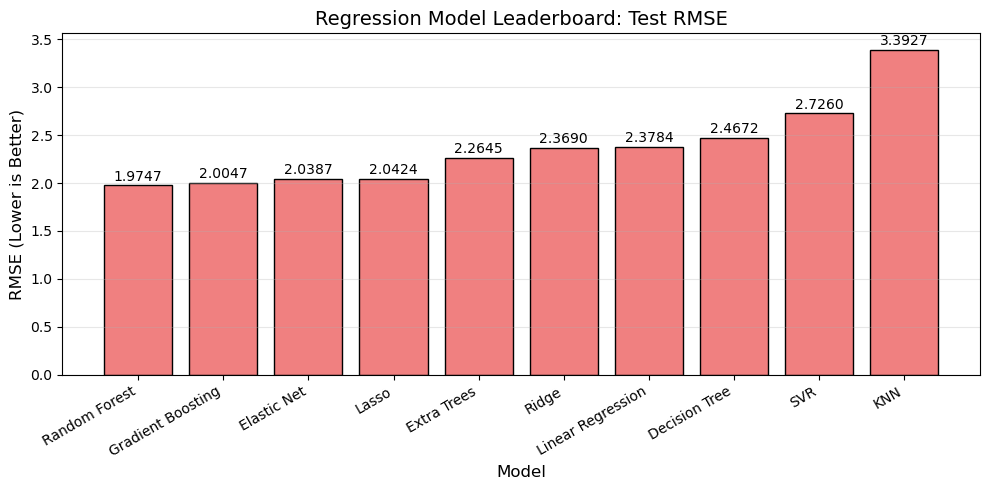

In [92]:
# Plot updated RMSE rankings to visually contrast performance
plt.figure(figsize=(10, 5))
plt.bar(model_comparison_table["Model"], model_comparison_table["RMSE"], color="lightcoral", edgecolor="black")
plt.title("Regression Model Leaderboard: Test RMSE", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("RMSE (Lower is Better)", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

for index, value in enumerate(model_comparison_table["RMSE"]):
    plt.text(index, value + 0.02, f"{value:.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

In [93]:
# Verification checks for model parameters and target shapes
assert et.n_estimators == 300, "Error: Extra Trees estimator count parameter does not match specified configuration (300)!"
assert len(et_predictions) == len(yte), "Error: Output shape mismatch between targets and Extra Trees predictions!"
assert len(gb_predictions) == len(yte), "Error: Output shape mismatch between targets and Gradient Boosting predictions!"
assert np.isfinite(et_predictions).all() and np.isfinite(gb_predictions).all(), "Error: Predictions contain non-finite values!"

print("Pipeline configuration and execution checks: PASSED")
print("SESSION 29 NOTEBOOK SECTION COMPLETED SUCCESSFULLY")

Pipeline configuration and execution checks: PASSED
SESSION 29 NOTEBOOK SECTION COMPLETED SUCCESSFULLY


# Session 30: Neural-Network (MLP) Regression Baseline
**Week 3 Artificial Neural Network Baseline**

In this section, we train a neural-network regressor using a **Multi-Layer Perceptron (MLP)** architecture. Neural networks are highly flexible non-linear function approximators, but they are exceptionally sensitive to the scale of input features due to the nature of weight updates and activation functions. 

To address this, we encapsulate `StandardScaler` and `MLPRegressor` inside a scikit-learn `Pipeline`. The network is configured with two hidden layers of $64$ and $32$ neurons, respectively, trained for a maximum of $1000$ iterations to ensure convergence on our feature space.


In [94]:
# Imports for Session 30
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Ensure previous session variables and helpers are active in the kernel memory
required_objects = ["Xtr_f", "Xte_f", "ytr", "yte", "eval_reg"]
missing_objects = [name for name in required_objects if name not in globals()]

if missing_objects:
    raise NameError(f"Prerequisite objects missing from prior sessions: {missing_objects}. Please run the preceding cells first.")
else:
    print("Verification passed. Core baseline variables and evaluations are loaded.")


Verification passed. Core baseline variables and evaluations are loaded.


In [95]:
# Initialize scaled Multi-Layer Perceptron Regressor inside a pipeline
mlp_pipeline = make_pipeline(
    StandardScaler(),
    MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
)

# Fit the MLP pipeline on the training data
mlp_pipeline.fit(Xtr_f, ytr)

# Generate test predictions
mlp_predictions = mlp_pipeline.predict(Xte_f)

# Evaluate predictions using the project's evaluation metrics
mlp_metrics = eval_reg(yte, mlp_predictions)

# Standalone comparison dataframe for Session 30
session30_results = pd.DataFrame([
    {"Model": "MLP Regressor", **mlp_metrics}
])

print("Session 30 Standalone Results:")
display(session30_results.round(4))


Session 30 Standalone Results:


,Model,MAE,RMSE,R2
0,MLP Regressor,2.0203,2.7846,0.6218


In [96]:
# Path to cumulative metrics tracker
comparison_path = PROJECT_ROOT / "reports" / "tables" / "model_comparison_table.csv"

# Structure the Session 30 row matching the cumulative schema
mlp_row = pd.DataFrame([{
    "Session": 30,
    "Week": 3,
    "Task Type": "Regression",
    "Scenario": "Full-information",
    "Feature Set": "X_full",
    "Target": "G3",
    "Model": "MLP Regressor",
    "Regularization": "MLP (64, 32) Pipeline",
    "Alpha": None,
    "L1 Ratio": None,
    "MAE": mlp_metrics["MAE"],
    "RMSE": mlp_metrics["RMSE"],
    "R2": mlp_metrics["R2"]
}])

if comparison_path.exists():
    model_comparison_table = pd.read_csv(comparison_path)
    # Clear prior historical runs of Session 30 rows to prevent duplicated rows upon notebook re-runs
    if "Session" in model_comparison_table.columns:
        model_comparison_table = model_comparison_table[model_comparison_table["Session"] != 30].copy()
    model_comparison_table = pd.concat([model_comparison_table, mlp_row], ignore_index=True, sort=False)
else:
    model_comparison_table = mlp_row.copy()

# Sort globally by the primary ranking metric (test RMSE)
model_comparison_table = model_comparison_table.sort_values(by="RMSE", ascending=True).reset_index(drop=True)

# Re-assign structural rank index starting at 1
if "RMSE Rank" in model_comparison_table.columns:
    model_comparison_table = model_comparison_table.drop(columns=["RMSE Rank"])
model_comparison_table.insert(0, "RMSE Rank", range(1, len(model_comparison_table) + 1))

# Export updated tables
tables_dir = PROJECT_ROOT / "reports" / "tables"
tables_dir.mkdir(parents=True, exist_ok=True)

model_comparison_table.to_csv(comparison_path, index=False)
session30_standalone_path = tables_dir / "session30_mlp_regression_row.csv"
mlp_row.to_csv(session30_standalone_path, index=False)

print("Cumulative comparison table updated successfully:")
print(comparison_path)
display(model_comparison_table.round(4))


Cumulative comparison table updated successfully:
/home/nikhil/Desktop/VSCode/GSSRP/student-performance-prediction-ml/reports/tables/model_comparison_table.csv


/tmp/ipykernel_7481/3822758221.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  model_comparison_table = pd.concat([model_comparison_table, mlp_row], ignore_index=True, sort=False)


,RMSE Rank,Session,Week,Task Type,Scenario,Feature Set,Target,Model,Regularization,Alpha,L1 Ratio,MAE,RMSE,R2
0,1,28.0,3.0,Regression,Full-information,X_full,G3,Random Forest,Ensemble (300 Trees),NaN,NaN,1.1706,1.9747,0.8098
1,2,29.0,3.0,Regression,Full-information,X_full,G3,Gradient Boosting,Boosting Ensemble,NaN,NaN,1.1594,2.0047,0.8040
2,3,25.0,3.0,Regression,Full-information,X_full,G3,Elastic Net,L1+L2,1.0,0.5,1.2555,2.0387,0.7973
3,4,25.0,3.0,Regression,Full-information,X_full,G3,Lasso,L1,1.0,NaN,1.2181,2.0424,0.7966
4,5,29.0,3.0,Regression,Full-information,X_full,G3,Extra Trees,Ensemble (300 Trees),NaN,NaN,1.3312,2.2645,0.7499
5,6,25.0,3.0,Regression,Full-information,X_full,G3,Ridge,L2,1.0,NaN,1.6354,2.3690,0.7263
6,7,25.0,3.0,Regression,Full-information,X_full,G3,Linear Regression,NaN,NaN,NaN,1.6467,2.3784,0.7241
7,8,27.0,3.0,Regression,Full-information,X_full,G3,Decision Tree,Depth-Limited,NaN,NaN,1.3572,2.4672,0.7031
8,9,NaN,NaN,NaN,NaN,NaN,NaN,SVR,NaN,NaN,NaN,1.8367,2.7260,0.6376
9,10,30.0,3.0,Regression,Full-information,X_full,G3,MLP Regressor,"MLP (64, 32) Pipeline",NaN,NaN,2.0203,2.7846,0.6218


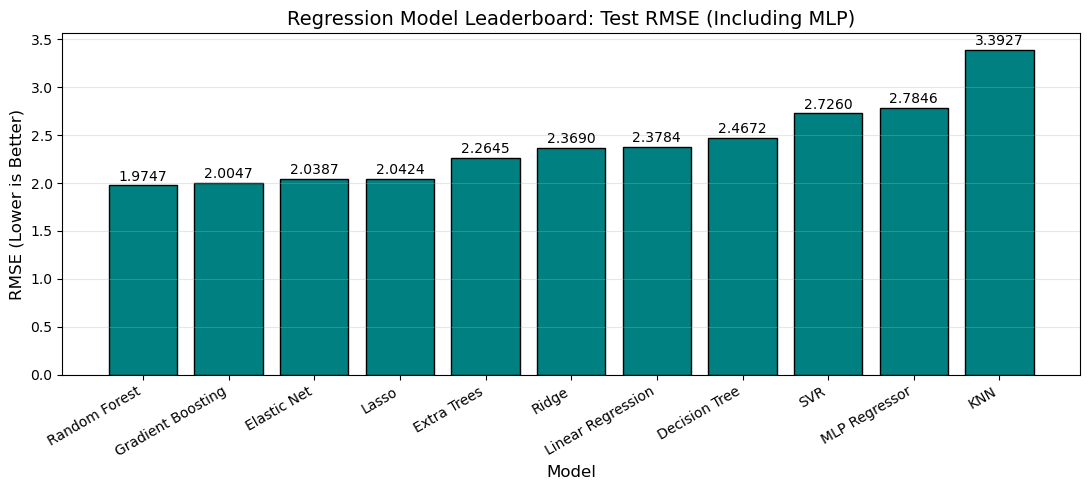

In [97]:
# Plot updated RMSE rankings to visually contrast performance across all sessions
plt.figure(figsize=(11, 5))
plt.bar(model_comparison_table["Model"], model_comparison_table["RMSE"], color="teal", edgecolor="black")
plt.title("Regression Model Leaderboard: Test RMSE (Including MLP)", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("RMSE (Lower is Better)", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)

for index, value in enumerate(model_comparison_table["RMSE"]):
    plt.text(index, value + 0.02, f"{value:.4f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()


In [98]:
# Access components within pipeline
scaler_step = mlp_pipeline.steps[0][1]
mlp_step = mlp_pipeline.steps[1][1]

# Verification checks for network parameters and output shape
assert isinstance(scaler_step, StandardScaler), "Error: First step of the pipeline must be StandardScaler!"
assert isinstance(mlp_step, MLPRegressor), "Error: Second step of the pipeline must be MLPRegressor!"
assert mlp_step.hidden_layer_sizes == (64, 32), "Error: Network architecture must configure layers (64, 32)!"
assert mlp_step.max_iter == 1000, "Error: Max iterations parameter must be set to 1000!"
assert len(mlp_predictions) == len(yte), "Error: Output shape mismatch between targets and MLP predictions!"
assert np.isfinite(mlp_predictions).all(), "Error: Predictions contain non-finite values!"

print("Pipeline architecture and evaluation validations: PASSED")
print("SESSION 30 NOTEBOOK SECTION COMPLETED SUCCESSFULLY")


Pipeline architecture and evaluation validations: PASSED
SESSION 30 NOTEBOOK SECTION COMPLETED SUCCESSFULLY
